# IBM Customer Churn Prediction
Logistic Regression, Random Forest, XGBoost with Full Analysis

## Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.calibration import calibration_curve

## Load Dataset

In [6]:
df = pd.read_csv("ibm_churn_97_realistic.csv")
print(df.shape)
df.head()

(15000, 14)


,tenure_months,monthly_usage_hours,monthly_bill,complaints,support_tickets,satisfaction_score,payment_delay_days,last_login_days_ago,feature_usage_score,auto_renew,age,num_logins_per_week,referrals,churn
0,52,164,1874,2,4,9,35,20,7,0,21,8,3,0
1,15,81,2132,2,9,5,7,20,7,0,41,40,1,0
2,61,22,1561,3,3,4,35,16,6,0,36,40,3,0
3,21,107,986,4,4,4,24,14,3,0,42,40,0,1
4,24,74,755,4,9,3,39,3,6,1,64,16,4,1


## Missing Data Analysis

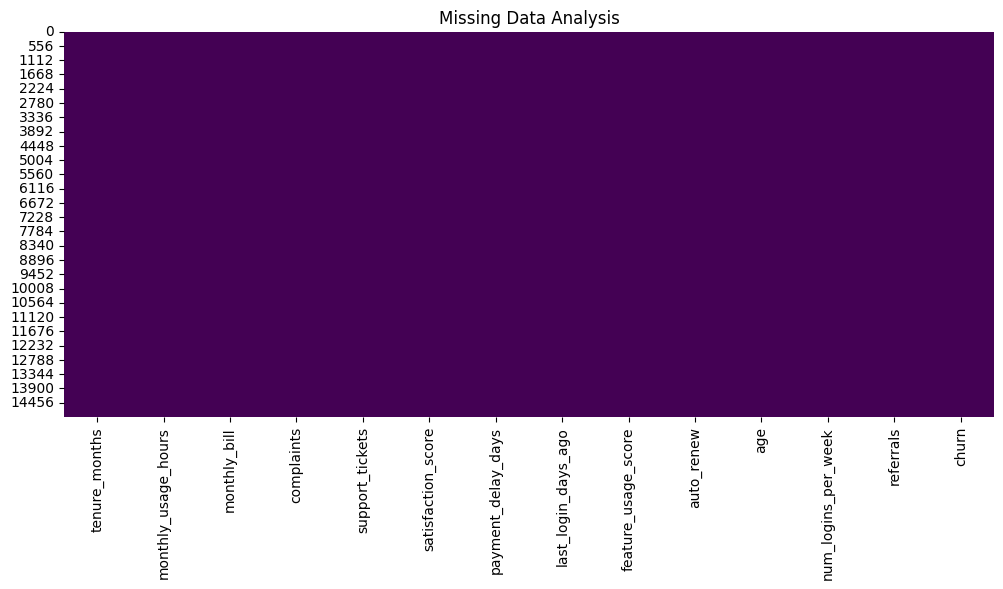

tenure_months          0
monthly_usage_hours    0
monthly_bill           0
complaints             0
support_tickets        0
satisfaction_score     0
payment_delay_days     0
last_login_days_ago    0
feature_usage_score    0
auto_renew             0
age                    0
num_logins_per_week    0
referrals              0
churn                  0
dtype: int64


In [7]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Analysis")
plt.show()

print(df.isnull().sum())

## Churn Distribution

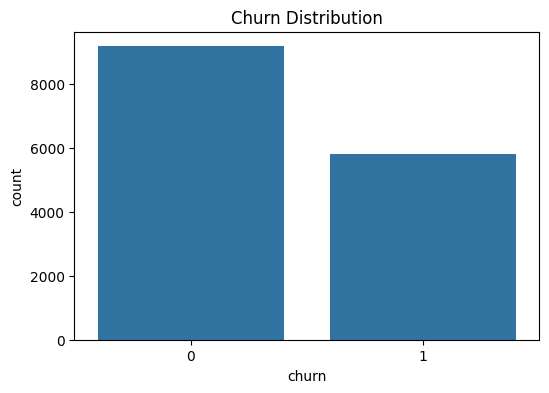

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

## Distribution of Key Numerical Features

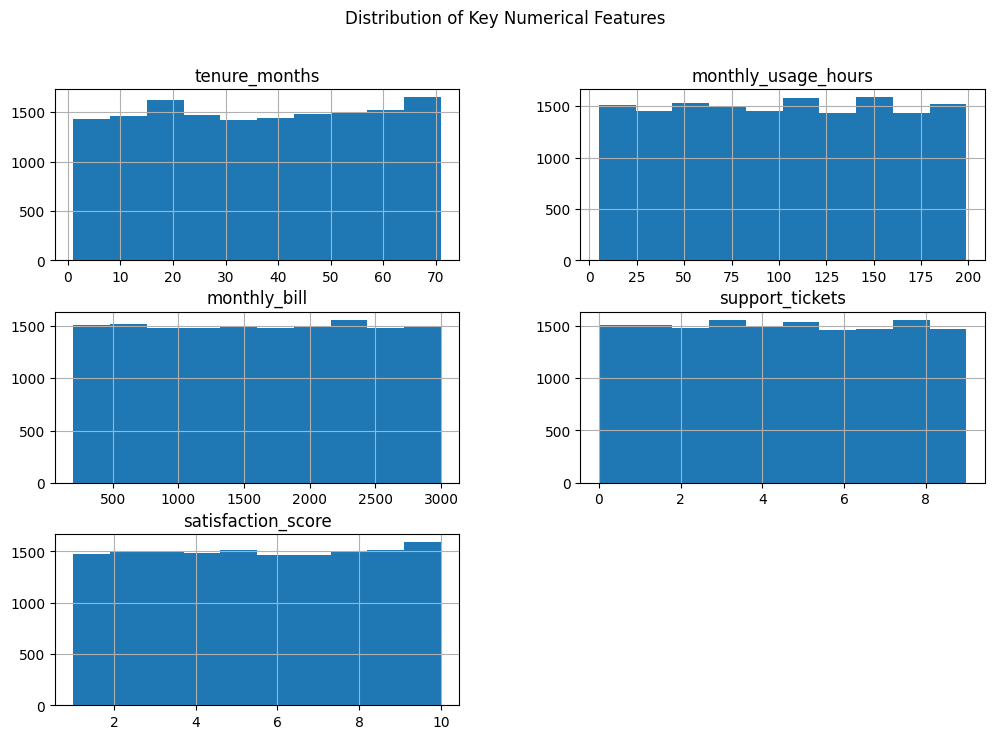

In [9]:
num_cols = ['tenure_months','monthly_usage_hours','monthly_bill',
            'support_tickets','satisfaction_score']

df[num_cols].hist(figsize=(12,8))
plt.suptitle("Distribution of Key Numerical Features")
plt.show()

## Boxplot: Churn vs Retained

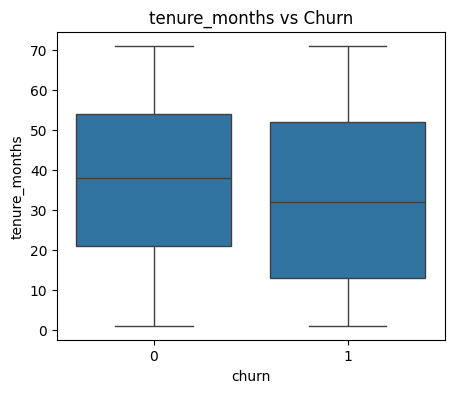

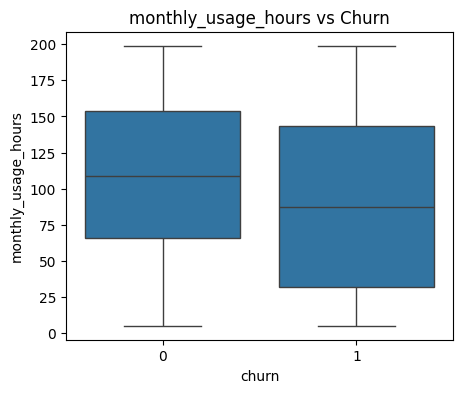

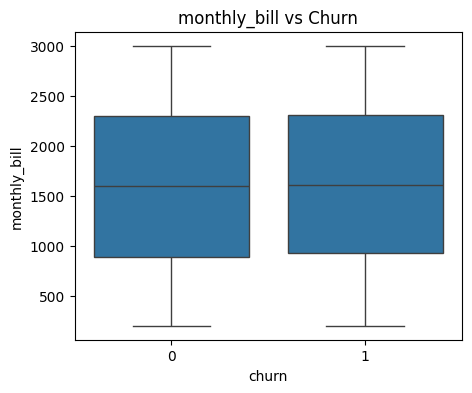

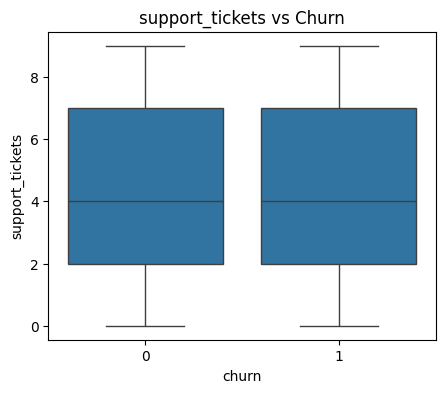

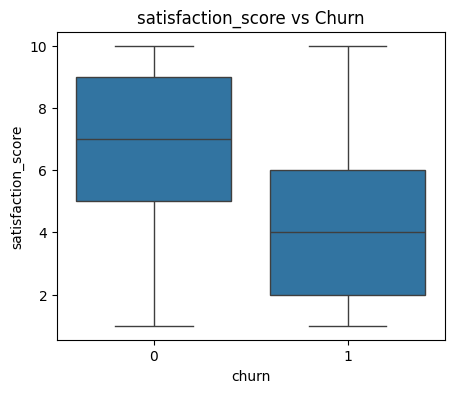

In [10]:
for col in num_cols:
    plt.figure(figsize=(5,4))
    sns.boxplot(x='churn', y=col, data=df)
    plt.title(f"{col} vs Churn")
    plt.show()

## Encode Categorical Features

In [11]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

## Correlation & Feature Selection

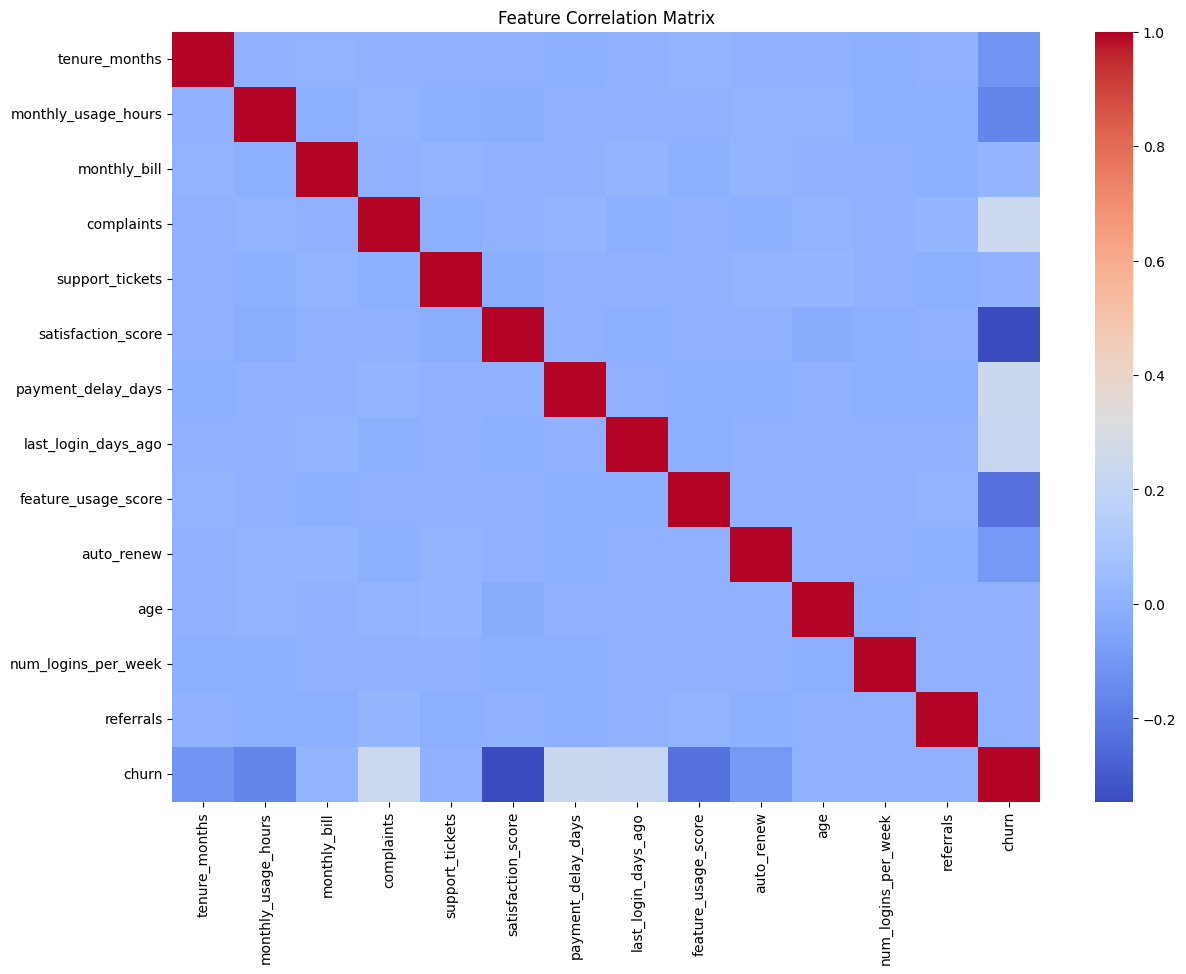

In [12]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

corr_target = df.corr()['churn'].abs()
selected_features = corr_target[corr_target > 0.02].index
df = df[selected_features]

## Train Test Split

In [13]:
X = df.drop("churn", axis=1)
y = df["churn"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Train Models

In [14]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:56:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

## Predictions

In [15]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

lr_prob = lr.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
xgb_prob = xgb.predict_proba(X_test)[:,1]

## Confusion Matrices

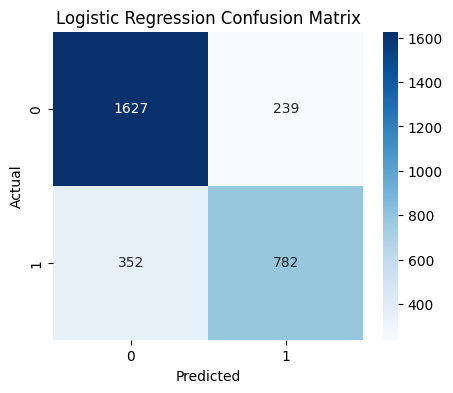

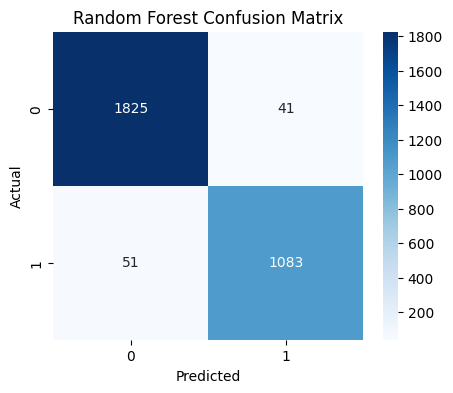

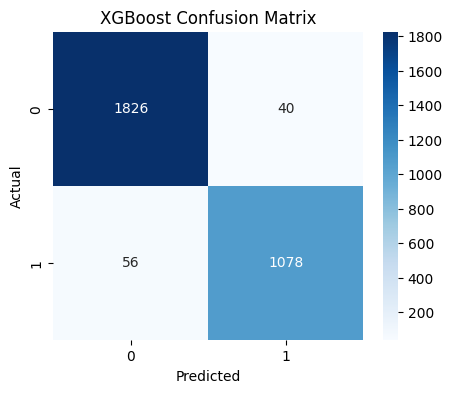

In [16]:
models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, pred),
                annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## ROC Curve

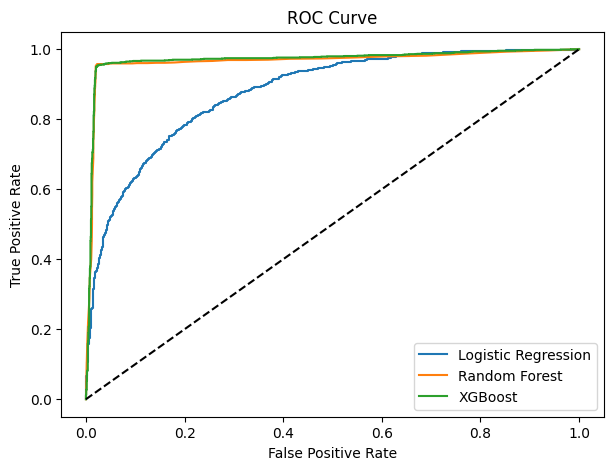

In [17]:
plt.figure(figsize=(7,5))

fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label="Logistic Regression")

fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label="Random Forest")

fpr, tpr, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr, tpr, label="XGBoost")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Calibration Plot

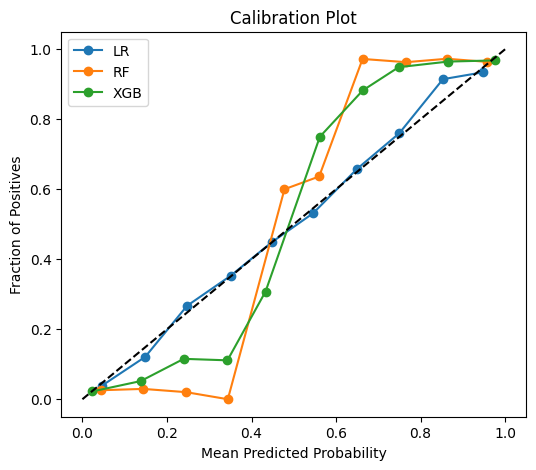

In [18]:
plt.figure(figsize=(6,5))

for name, prob in [("LR", lr_prob), ("RF", rf_prob), ("XGB", xgb_prob)]:
    prob_true, prob_pred = calibration_curve(y_test, prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=name)

plt.plot([0,1],[0,1],'k--')
plt.title("Calibration Plot")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.show()

## Accuracy & Classification Report

In [19]:
print("Logistic Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nXGBoost Classification Report\n")
print(classification_report(y_test, xgb_pred))

Logistic Accuracy: 0.803
Random Forest Accuracy: 0.9693333333333334
XGBoost Accuracy: 0.968

XGBoost Classification Report

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1866
           1       0.96      0.95      0.96      1134

    accuracy                           0.97      3000
   macro avg       0.97      0.96      0.97      3000
weighted avg       0.97      0.97      0.97      3000

